In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_copy import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
import jax
import jax.numpy as jnp
import equinox as eqx

def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class Example(TripletModel):
    # unconstrained trainable parameters for 2x2 lower-triangular factor
    K: jax.Array

    def __init__(self, der_K: jax.Array, key: jax.Array):
        """
        der_K is the user-facing physical 3-vector:
            [k_ss, k_sb, k_bb]

        We convert it to unconstrained parameters of a Cholesky factor L
        so that the induced 2x2 matrix B = L L^T is always symmetric PSD.
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # PSD condition for
        # [[k_ss, sqrt(2) k_sb],
        #  [sqrt(2) k_sb, k_bb]]
        if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
            raise ValueError(
                "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
                "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
            )

        # Convert physical coefficients to Cholesky factor entries
        l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
        l21 = jnp.sqrt(2.0) * k_sb0 / l11
        rem = k_bb0 - l21**2
        l22 = jnp.sqrt(jnp.maximum(rem, eps))

        # Store unconstrained parameters
        p0 = inv_softplus(l11 - eps)
        p1 = l21
        p2 = inv_softplus(l22 - eps)

        self.K = jnp.array([p0, p1, p2])

    def _vec_to_L(self, p: jax.Array) -> jax.Array:
        eps = 1e-6
        p = jnp.ravel(p)
        return jnp.array([
            [jax.nn.softplus(p[0]) + eps, 0.0],
            [p[1],                        jax.nn.softplus(p[2]) + eps],
        ])

    def get_K_entries(self) -> jax.Array:
        """
        Returns the physical coefficients [k_ss, k_sb, k_bb], guaranteed PSD.
        """
        L = self._vec_to_L(self.K)
        B = L @ L.T

        # B = [[k_ss, sqrt(2) k_sb],
        #      [sqrt(2) k_sb, k_bb]]
        k_ss = B[0, 0]
        k_sb = B[0, 1] / jnp.sqrt(2.0)
        k_bb = B[1, 1]

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self) -> jax.Array:
        """
        Full structured stiffness matrix acting on [e0, e1, eb]:
            [[k_ss,   0,   k_sb],
             [  0,  k_ss,  k_sb],
             [k_sb, k_sb,  k_bb]]
        """
        k_ss, k_sb, k_bb = self.get_K_entries()
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain):
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries()

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [3]:
train_datafile = "experiment_data/train.npz"
valid_datafile = "experiment_data/valid.npz"

init_K=jnp.array([0.1, 0.001, 0.05])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=5e-2, init_K=init_K )

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Initial training loss: 1.27852e-04
K: [-0.98901915  0.00447214 -1.3842085 ]
grad K: [ 3.17484438e-05 -2.21025960e-04  1.87937058e-04]
loss finite? True
grad finite? True
Step 0    | LR: 5.000e-02  | Train: 1.27852e-04  | Valid: 1.10742e-04  | K: [-1.03900341  0.05446987 -1.43420584]
Step 10   | LR: 4.996e-02  | Train: 1.31104e-05  | Valid: 9.67694e-06  | K: [-1.53409264  0.04389697 -1.93177255]
Step 20   | LR: 4.982e-02  | Train: 5.33636e-06  | Valid: 3.35087e-06  | K: [-1.82314569 -0.04329272 -2.20358794]
Step 30   | LR: 4.960e-02  | Train: 2.61525e-06  | Valid: 3.07237e-06  | K: [-1.69592071 -0.04845225 -2.29323824]
Step 40   | LR: 4.930e-02  | Train: 2.62783e-06  | Valid: 4.04347e-06  | K: [-1.69224977 -0.05763855 -2.3098474 ]
Step 50   | LR: 4.890e-02  | Train: 2.58016e-06  | Valid: 3.00643e-06  | K: [-1.74738445 -0.05389358 -2.30112548]
Step 60   | LR: 4.843e-02  | Train: 2.32005e-06  | Valid: 2.86738e-06  | K: [-1.709807   -0.0495986  -2.28263383]
Step 70   | LR: 4.787e-02  | Tra

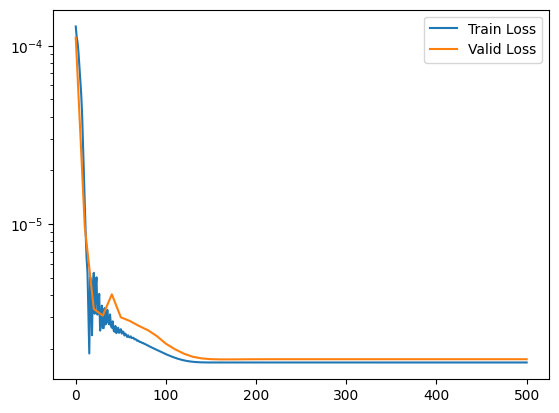

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (8, 40, 8)
xb.shape (8, 40, 8)
pred.shape (8, 40, 11)
valid.qs.shape (8, 40, 11)
train.qs.shape (8, 40, 11)


In [9]:
# animate(valid.qs)

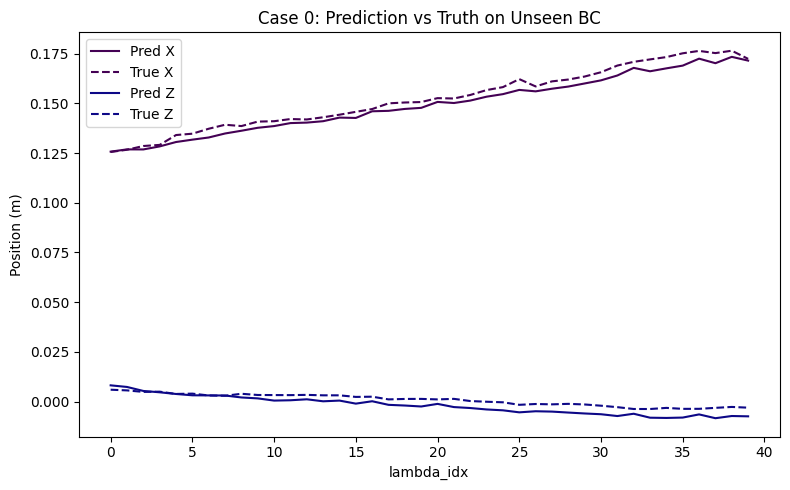

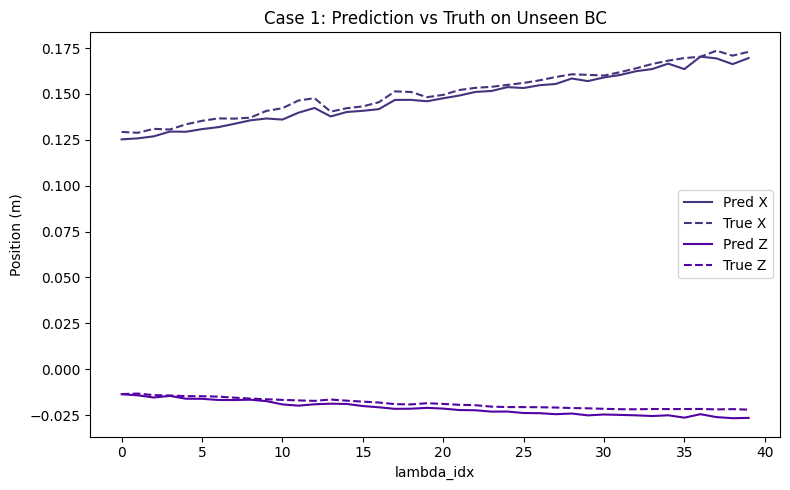

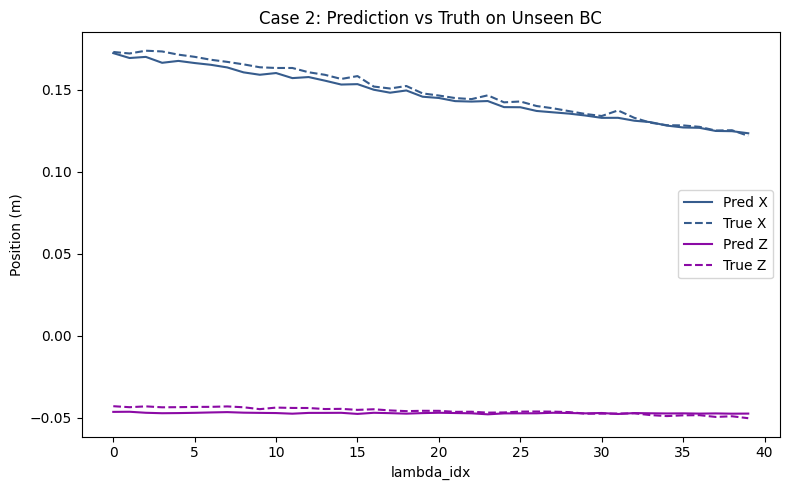

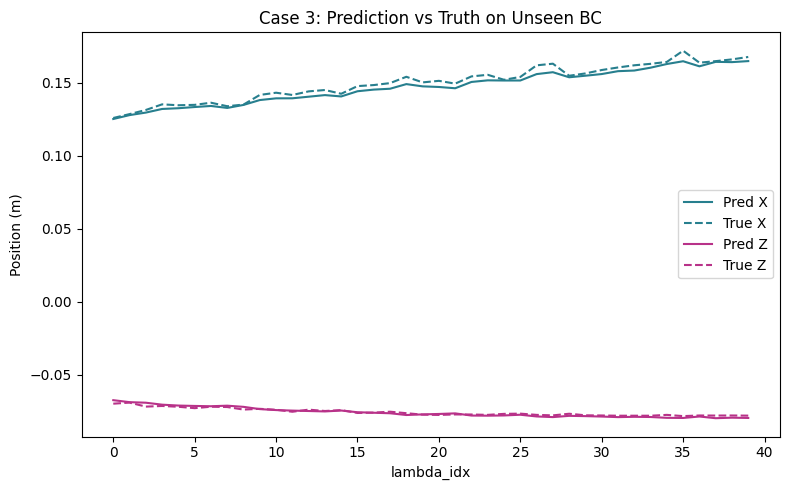

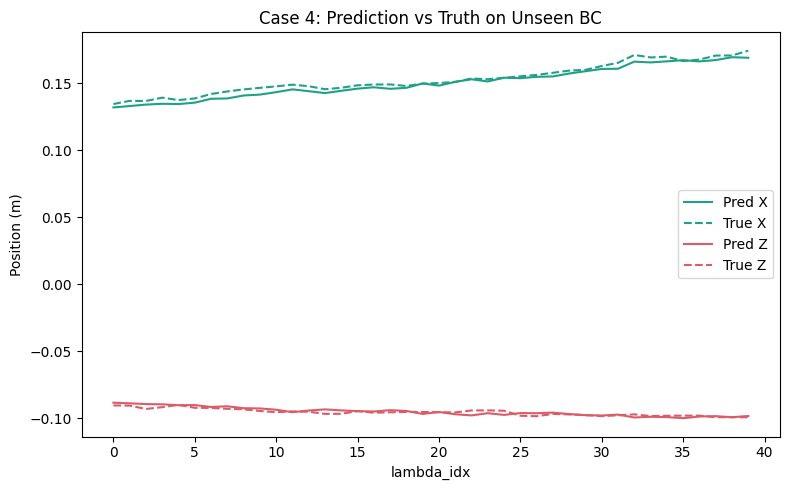

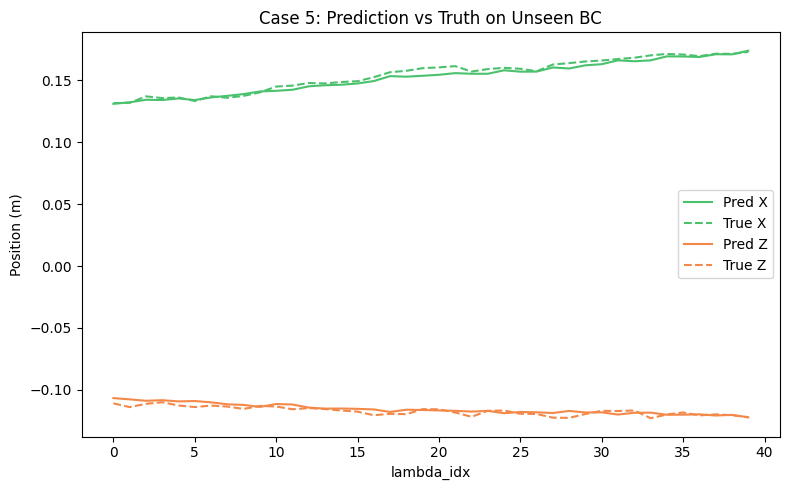

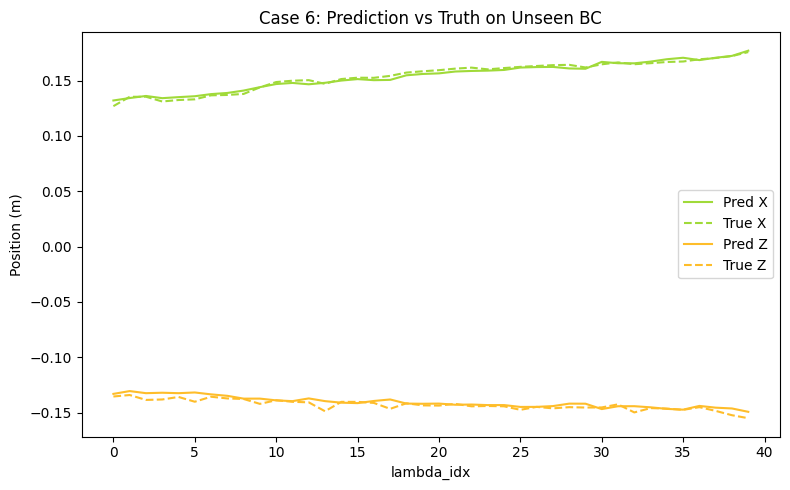

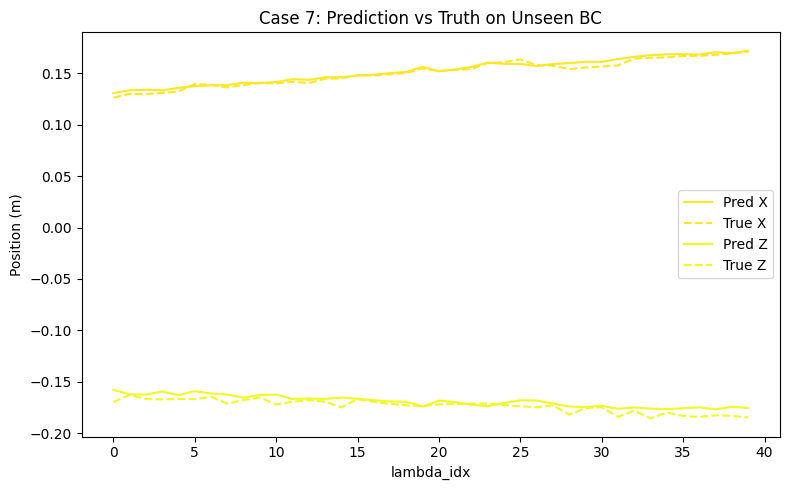

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 4], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 4], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 6], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 6], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[0.         0.         0.         0.         0.16428576 0.
  0.01229775 0.         0.32682654 0.         0.13977266]
 [0.         0.         0.         0.         0.16303527 0.
  0.01308039 0.         0.32530566 0.         0.13923934]
 [0.         0.         0.         0.         0.15640293 0.
  0.01301728 0.         0.3172655  0.         0.13868152]]
final:  [[ 0.          0.          0.          0.          0.16309561  0.
  -0.15344538  0.          0.32634914  0.         -0.18034504]
 [ 0.          0.          0.          0.          0.16026018  0.
  -0.15141121  0.          0.3255293   0.         -0.18462522]
 [ 0.          0.          0.          0.          0.15990571  0.
  -0.15042114  0.          0.31977792  0.         -0.18008941]]
Validation BC:
init:  [[0.         0.         0.         0.         0.13856692 0.
  0.0039613  0.         0.27440777 0.         0.11285062]
 [0.         0.         0.         0.         0.14081248 0.
  0.00335446 0.         0.277

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[0.         0.         0.         0.         0.17430091 0.
  0.01355381 0.         0.33866367 0.         0.13729598]
 [0.         0.         0.         0.         0.16942554 0.
  0.01341526 0.         0.33447406 0.         0.1386963 ]
 [0.         0.         0.         0.         0.1670495  0.
  0.01400291 0.         0.32791504 0.         0.13421736]]
final position of the middle node in the training data:  [[ 0.          0.          0.          0.          0.16568868  0.
  -0.15070113  0.          0.33929003  0.         -0.18367317]
 [ 0.          0.          0.          0.          0.164255    0.
  -0.15390902  0.          0.33209236  0.         -0.17952158]
 [ 0.          0.          0.          0.          0.1639525   0.
  -0.15416049  0.          0.32664102  0.         -0.1765561 ]]


In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13405191 0.
  0.00387515 0.         0.26362414 0.         0.11435032]
 [0.         0.         0.         0.         0.13473146 0.
  0.00403559 0.         0.26587429 0.         0.11339072]
 [0.         0.         0.         0.         0.13722261 0.
  0.00311249 0.         0.26794605 0.         0.11373071]]
final position of the middle node in the validation data:  [[ 0.          0.          0.          0.          0.13252028  0.
  -0.16677108  0.          0.26937761  0.         -0.20982013]
 [ 0.          0.          0.          0.          0.13982214  0.
  -0.16692505  0.          0.27305123  0.         -0.20214286]
 [ 0.          0.          0.          0.          0.13888024  0.
  -0.16469997  0.          0.27458906  0.         -0.20636286]]


In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[0.         0.         0.         0.         0.13054689 0.
  0.0038568  0.         0.26362414 0.         0.11435032]
 [0.         0.         0.         0.         0.13173639 0.
  0.00319733 0.         0.26587429 0.         0.11339072]
 [0.         0.         0.         0.         0.13282385 0.
  0.00314375 0.         0.26794605 0.         0.11373071]]
final position of the middle node in the prediction:  [[ 0.          0.          0.          0.          0.13598239  0.
  -0.16314408  0.          0.26937761  0.         -0.20982013]
 [ 0.          0.          0.          0.          0.13772358  0.
  -0.15917411  0.          0.27305123  0.         -0.20214286]
 [ 0.          0.          0.          0.          0.13846835  0.
  -0.16150295  0.          0.27458906  0.         -0.20636286]]
